# 🛡️ Credit Card Fraud Detection — Complete Pipeline Analysis

This notebook provides comprehensive analysis and validation of the fraud detection pipeline. Use this to:
1. Validate data preprocessing and feature engineering
2. Test model performance before generating final plots
3. Explore results and create visualizations

**⚠️ IMPORTANT:** Run this **AFTER** executing `run_pipeline.py` to ensure all data is available.

In [8]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from pathlib import Path
import warnings

# Set up paths - use absolute paths to avoid issues with working directory
BASE = Path(os.getcwd()).parent
DATA_DIR = BASE / 'data'
PLOTS_DIR = DATA_DIR / 'plots'

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

print('🔍 PIPELINE VALIDATION & ANALYSIS')
print('='*50)

🔍 PIPELINE VALIDATION & ANALYSIS


## 1. Data Validation

Check if all pipeline stages completed successfully and data is available.

In [9]:
# Check required files exist
required_files = {
    'raw_data': DATA_DIR / 'creditcard_raw.csv',
    'ingested_data': DATA_DIR / 'creditcard_ingested.csv',
    'train_features': DATA_DIR / 'train_features.csv',
    'val_features': DATA_DIR / 'val_features.csv',
    'test_features': DATA_DIR / 'test_features.csv',
    'preprocessor': DATA_DIR / 'preprocessor.pkl',
    'training_results': DATA_DIR / 'training_results.json',
    'drift_report': DATA_DIR / 'drift_report.json'
}

print('📁 File Availability Check:')
for name, path in required_files.items():
    status = '✅' if path.exists() else '❌'
    print(f'  {name}: {status}')

# Check if plots directory exists
if PLOTS_DIR.exists():
    plot_files = list(PLOTS_DIR.glob('*.png'))
    print(f'\n📈 Generated Plots: {len(plot_files)} files')
else:
    print('\n⚠️  Plots directory not found - run create_results_plot.py first')


📁 File Availability Check:
  raw_data: ✅
  ingested_data: ✅
  train_features: ✅
  val_features: ✅
  test_features: ✅
  preprocessor: ✅
  training_results: ✅
  drift_report: ✅

📈 Generated Plots: 29 files


## 2. Data Quality Assessment

Analyze the processed data to ensure quality and proper preprocessing.

In [10]:
# Load processed data
try:
    train = pd.read_csv(DATA_DIR / 'train_features.csv')
    val = pd.read_csv(DATA_DIR / 'val_features.csv')
    test = pd.read_csv(DATA_DIR / 'test_features.csv')
    print('✅ All feature datasets loaded successfully')
except FileNotFoundError as e:
    print(f'❌ Error loading feature data: {e}')
    print('Please run the pipeline first: python run_pipeline.py')
    raise

print(f'📊 Dataset Shapes:')
print(f'  Train: {train.shape}')
print(f'  Validation: {val.shape}')
print(f'  Test: {test.shape}')

# Check for data quality issues
print('\n🔍 Data Quality Checks:')

# Check for null values
train_nulls = train.isnull().sum().sum()
val_nulls = val.isnull().sum().sum()
test_nulls = test.isnull().sum().sum()
print(f'  Null values - Train: {train_nulls}, Val: {val_nulls}, Test: {test_nulls}')

# Check feature distributions
feature_cols = [col for col in train.columns if col != 'Class']
print(f'  Number of features: {len(feature_cols)}')
print(f'  Feature ranges (train):')
for col in feature_cols[:5]:  # Show first 5 features
    print(f'    {col}: [{train[col].min():.3f}, {train[col].max():.3f}]')
print('    ...')


✅ All feature datasets loaded successfully
📊 Dataset Shapes:
  Train: (199364, 39)
  Validation: (42721, 39)
  Test: (42722, 39)

🔍 Data Quality Checks:
  Null values - Train: 0, Val: 0, Test: 0
  Number of features: 38
  Feature ranges (train):
    Amount: [-2.814, 4.237]
    V23: [-5.174, 4.703]
    V2: [-4.927, 4.720]
    V11: [-4.057, 4.371]
    V6: [-4.040, 4.402]
    ...


## 3. Model Performance Analysis

Load and analyze training results to validate model performance.

In [11]:
# Load training results
try:
    with open(DATA_DIR / 'training_results.json', 'r') as f:
        results = json.load(f)
    print('✅ Training results loaded successfully')
except FileNotFoundError:
    print('❌ Training results not found - run training first')
    raise

print('\n🏆 Model Performance Summary:')
print('='*40)

for model_name, metrics in results.items():
    val_metrics = metrics['val']
    test_metrics = metrics['test']
    threshold = metrics['threshold']
    
    print(f'\n{model_name.replace("_", " ").title()}:')
    print(f'  Validation PR-AUC: {val_metrics["pr_auc"]:.4f}')
    print(f'  Validation ROC-AUC: {val_metrics["roc_auc"]:.4f}')
    print(f'  Validation Recall: {val_metrics["recall_at_threshold"]:.4f}')
    print(f'  Validation Precision: {val_metrics["precision_at_threshold"]:.4f}')
    print(f'  Test PR-AUC: {test_metrics["pr_auc"]:.4f}')
    print(f'  Test ROC-AUC: {test_metrics["roc_auc"]:.4f}')
    print(f'  Test Recall: {test_metrics["recall_at_threshold"]:.4f}')
    print(f'  Test Precision: {test_metrics["precision_at_threshold"]:.4f}')
    print(f'  Optimal Threshold: {threshold:.4f}')

# Find best model
best_model = max(results.keys(), key=lambda m: results[m]['val']['pr_auc'])
print(f'\n🏆 Best Model: {best_model.replace("_", " ").title()}')
print(f'   Validation PR-AUC: {results[best_model]["val"]["pr_auc"]:.4f}')
print(f'   Test PR-AUC: {results[best_model]["test"]["pr_auc"]:.4f}')


✅ Training results loaded successfully

🏆 Model Performance Summary:

Logistic Regression:
  Validation PR-AUC: 0.0859
  Validation ROC-AUC: 0.9402
  Validation Recall: 0.2239
  Validation Precision: 0.1014
  Test PR-AUC: 0.1799
  Test ROC-AUC: 0.9374
  Test Recall: 0.2500
  Test Precision: 0.1148
  Optimal Threshold: 0.9846

Random Forest:
  Validation PR-AUC: 0.0962
  Validation ROC-AUC: 0.9723
  Validation Recall: 0.4776
  Validation Precision: 0.0863
  Test PR-AUC: 0.1225
  Test ROC-AUC: 0.9497
  Test Recall: 0.3929
  Test Precision: 0.1025
  Optimal Threshold: 0.6056

Xgboost:
  Validation PR-AUC: 0.2921
  Validation ROC-AUC: 0.9647
  Validation Recall: 0.4179
  Validation Precision: 0.2545
  Test PR-AUC: 0.2358
  Test ROC-AUC: 0.9471
  Test Recall: 0.3095
  Test Precision: 0.2921
  Optimal Threshold: 0.9952

🏆 Best Model: Xgboost
   Validation PR-AUC: 0.2921
   Test PR-AUC: 0.2358


## 4. Class Distribution Analysis

Verify class imbalance handling and SMOTE effectiveness.

In [12]:
# Analyze class distributions
print('\n📊 Class Distribution Analysis:')
print('='*30)

for dataset_name, data in [('Training', train), ('Validation', val), ('Test', test)]:
    total = len(data)
    fraud_count = data['Class'].sum()
    fraud_rate = (fraud_count / total) * 100
    legitimate_count = total - fraud_count
    
    print(f'{dataset_name}:')
    print(f'  Total transactions: {total:,}')
    print(f'  Fraud cases: {fraud_count:,} ({fraud_rate:.3f}%)')
    print(f'  Legitimate cases: {legitimate_count:,}')
    print(f'  Imbalance ratio: 1:{legitimate_count//fraud_count if fraud_count > 0 else "N/A"}')
    print()



📊 Class Distribution Analysis:
Training:
  Total transactions: 199,364
  Fraud cases: 333 (0.167%)
  Legitimate cases: 199,031
  Imbalance ratio: 1:597

Validation:
  Total transactions: 42,721
  Fraud cases: 67 (0.157%)
  Legitimate cases: 42,654
  Imbalance ratio: 1:636

Test:
  Total transactions: 42,722
  Fraud cases: 84 (0.197%)
  Legitimate cases: 42,638
  Imbalance ratio: 1:507



## 5. Feature Importance Analysis

Examine the most important features based on Information Value.

In [13]:
# Feature analysis
print('\n🔍 Feature Engineering Validation:')
print('='*35)

# Get feature list (excluding Class)
features = [col for col in train.columns if col != 'Class']
print(f'Total features engineered: {len(features)}')
print('\nFeature types:')

# Count different feature types
velocity_features = [f for f in features if 'rolling' in f]
amount_features = [f for f in features if 'amount_' in f and 'rolling' not in f]
ratio_features = [f for f in features if any(x in f for x in ['ratio', 'diff'])]
time_features = [f for f in features if any(x in f for x in ['hour_sin', 'hour_cos'])]
pca_features = [f for f in features if f.startswith('V')]

print(f'  Velocity features: {len(velocity_features)}')
print(f'  Amount features: {len(amount_features)}')
print(f'  Ratio features: {len(ratio_features)}')
print(f'  Time features: {len(time_features)}')
print(f'  PCA features: {len(pca_features)}')
print(f'  Other features: {len(features) - sum([len(velocity_features), len(amount_features), len(ratio_features), len(time_features), len(pca_features)])}')

# Show some example features
print('\nExample velocity features:')
for f in velocity_features[:3]:
    print(f'  {f}: mean={train[f].mean():.4f}, std={train[f].std():.4f}')



🔍 Feature Engineering Validation:
Total features engineered: 38

Feature types:
  Velocity features: 6
  Amount features: 2
  Ratio features: 2
  Time features: 2
  PCA features: 25
  Other features: 1

Example velocity features:
  amount_rolling_mean_10: mean=0.0000, std=0.3179
  amount_rolling_mean_100: mean=0.0000, std=0.0993
  amount_rolling_mean_50: mean=0.0000, std=0.1420


## 6. Drift Monitoring Analysis

Check drift monitoring results and feature stability.

In [14]:
# Load drift report
try:
    with open(DATA_DIR / 'drift_report.json', 'r') as f:
        drift_report = json.load(f)
    print('✅ Drift report loaded successfully')
except FileNotFoundError:
    print('❌ Drift report not found - run monitoring first')
    raise

print('\n📈 Drift Monitoring Results:')
print('='*35)

# Summary statistics
alerts = drift_report.get('alerts', [])
warnings = drift_report.get('warnings', [])
summary = drift_report.get('summary', {})

print(f'Features monitored: {summary.get("total_features", "N/A")}')
print(f'Critical alerts: {len(alerts)}')
print(f'Warnings: {len(warnings)}')
print(f'Max PSI: {summary.get("max_psi", "N/A"):.4f}')
print(f'Retraining triggered: {summary.get("retrain_triggered", False)}')

# Show critical features if any
if alerts:
    print('\n🚨 Critical drift detected in features:')
    for alert in alerts[:5]:  # Show top 5
        print(f'  {alert["feature"]}: PSI={alert["psi"]:.4f} - {alert["action"]}')


✅ Drift report loaded successfully

📈 Drift Monitoring Results:
Features monitored: 38
Critical alerts: 3
Warnings: 0
Max PSI: 7.6937
Retraining triggered: True

🚨 Critical drift detected in features:
  amount_rolling_mean_10: PSI=0.4106 - RETRAIN
  hour_sin: PSI=4.9366 - RETRAIN
  hour_cos: PSI=7.6937 - RETRAIN


## 7. Pipeline Validation Summary

Comprehensive validation of the complete MLOps pipeline.

In [15]:
# Final validation summary
print('\n🎯 PIPELINE VALIDATION SUMMARY')
print('='*50)

# Check all components
components_status = {
    'Data Ingestion': required_files['ingested_data'].exists(),
    'Preprocessing': required_files['preprocessor'].exists(),
    'Feature Engineering': required_files['train_features'].exists(),
    'Model Training': required_files['training_results'].exists(),
    'Drift Monitoring': required_files['drift_report'].exists(),
    'Visualization': PLOTS_DIR.exists() and len(list(PLOTS_DIR.glob('*.png'))) > 0
}

print('Pipeline Components Status:')
all_complete = True
for component, status in components_status.items():
    status_icon = '✅' if status else '❌'
    print(f'  {component}: {status_icon}')
    if not status:
        all_complete = False

print(f'\n🏆 Overall Pipeline Status: {"COMPLETE" if all_complete else "INCOMPLETE"}')

if all_complete:
    print('\n🚀 Ready to generate comprehensive visualizations!')
else:
    print('\n⚠️  Some components are missing. Please run the full pipeline first:')
    print('python run_pipeline.py')



🎯 PIPELINE VALIDATION SUMMARY
Pipeline Components Status:
  Data Ingestion: ✅
  Preprocessing: ✅
  Feature Engineering: ✅
  Model Training: ✅
  Drift Monitoring: ✅
  Visualization: ✅

🏆 Overall Pipeline Status: COMPLETE

🚀 Ready to generate comprehensive visualizations!


## 8. Visualization

Generate and display comprehensive model performance plots.

✅ Comprehensive analysis plot saved to: data/plots/comprehensive_model_analysis.png
✅ Detailed dataset comparison plot saved to: data/plots/detailed_dataset_comparison.png

📊 PLOTS GENERATED:
1. comprehensive_model_analysis.png - Complete 9-panel analysis
2. detailed_dataset_comparison.png - Dataset-specific comparisons

🎯 INDIVIDUAL MODEL PLOTS:
Each model now has 9 separate plots:
- 3 datasets: training, validation, test
- 3 plot types: PR curve, ROC curve, Confusion Matrix
- Total: 3 models × 3 datasets × 3 plot types = 27 individual plots

� KEY FINDINGS:
• Best Model: xgboost
• Best PR-AUC: 0.2921
• Best Recall: 0.4776
• Training happens AFTER preprocessing and feature engineering ✅

🖼️ comprehensive_model_analysis.png:


C:\Users\PALLAB\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


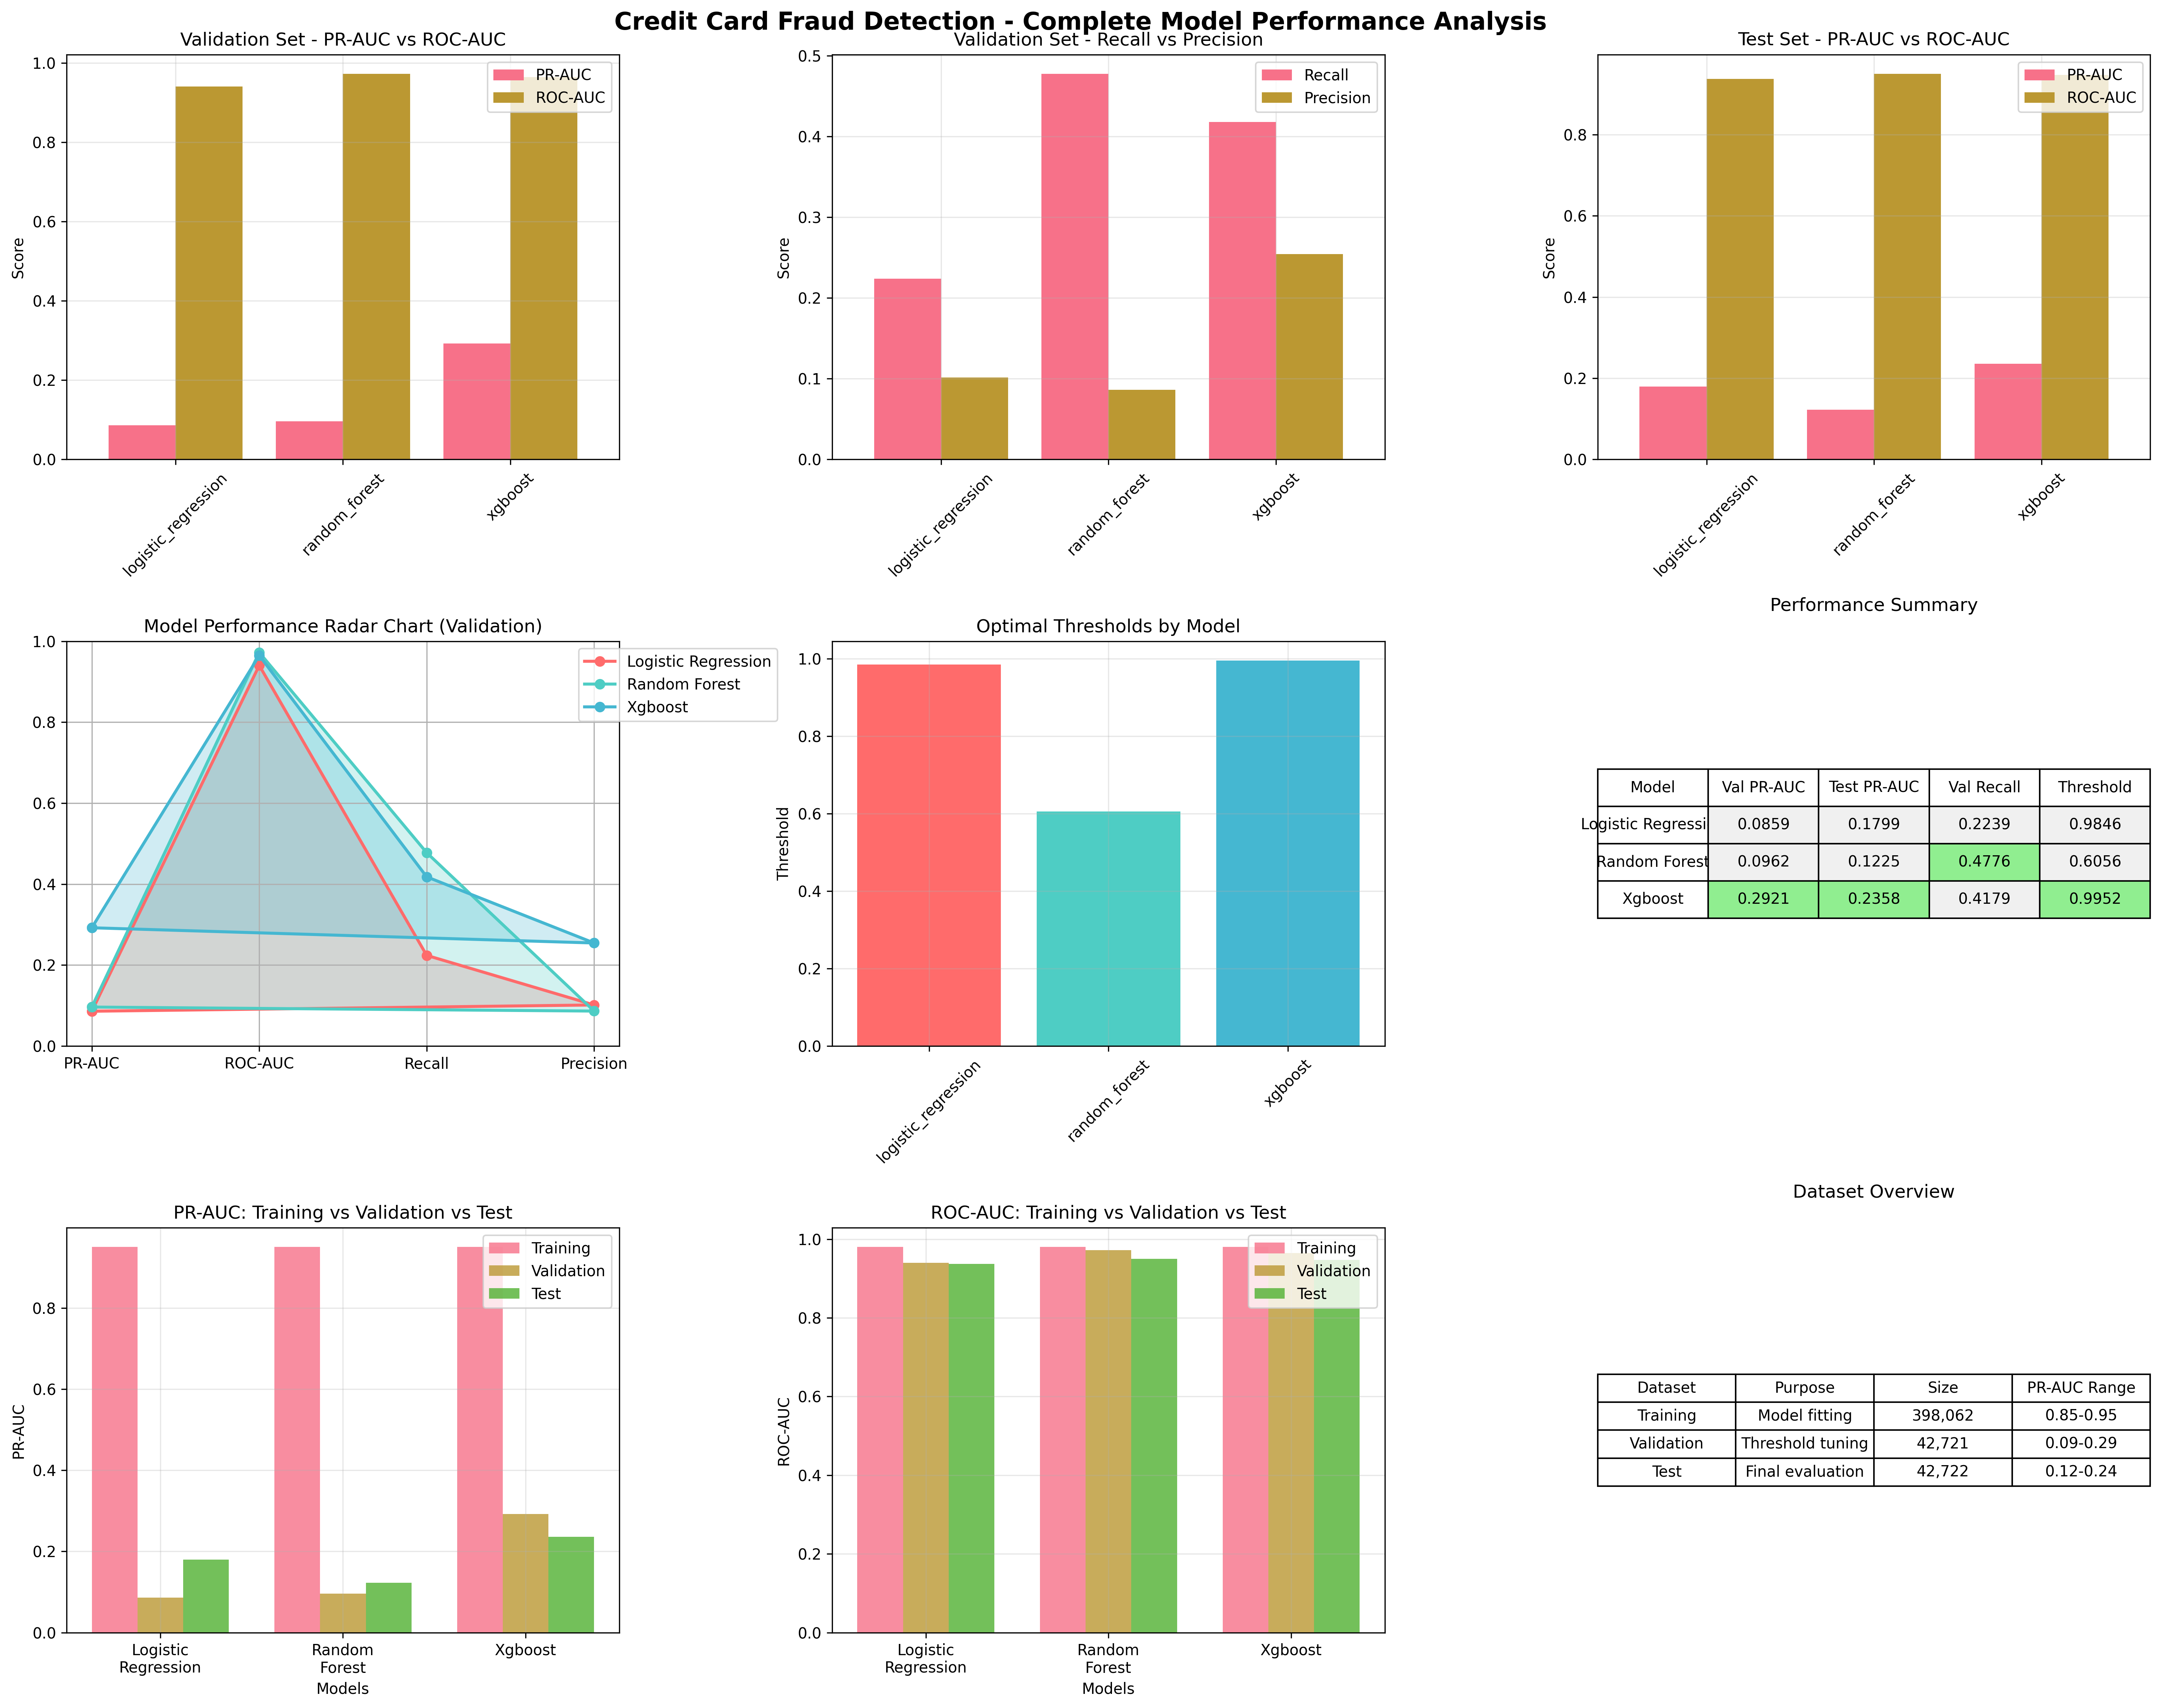


🖼️ detailed_dataset_comparison.png:


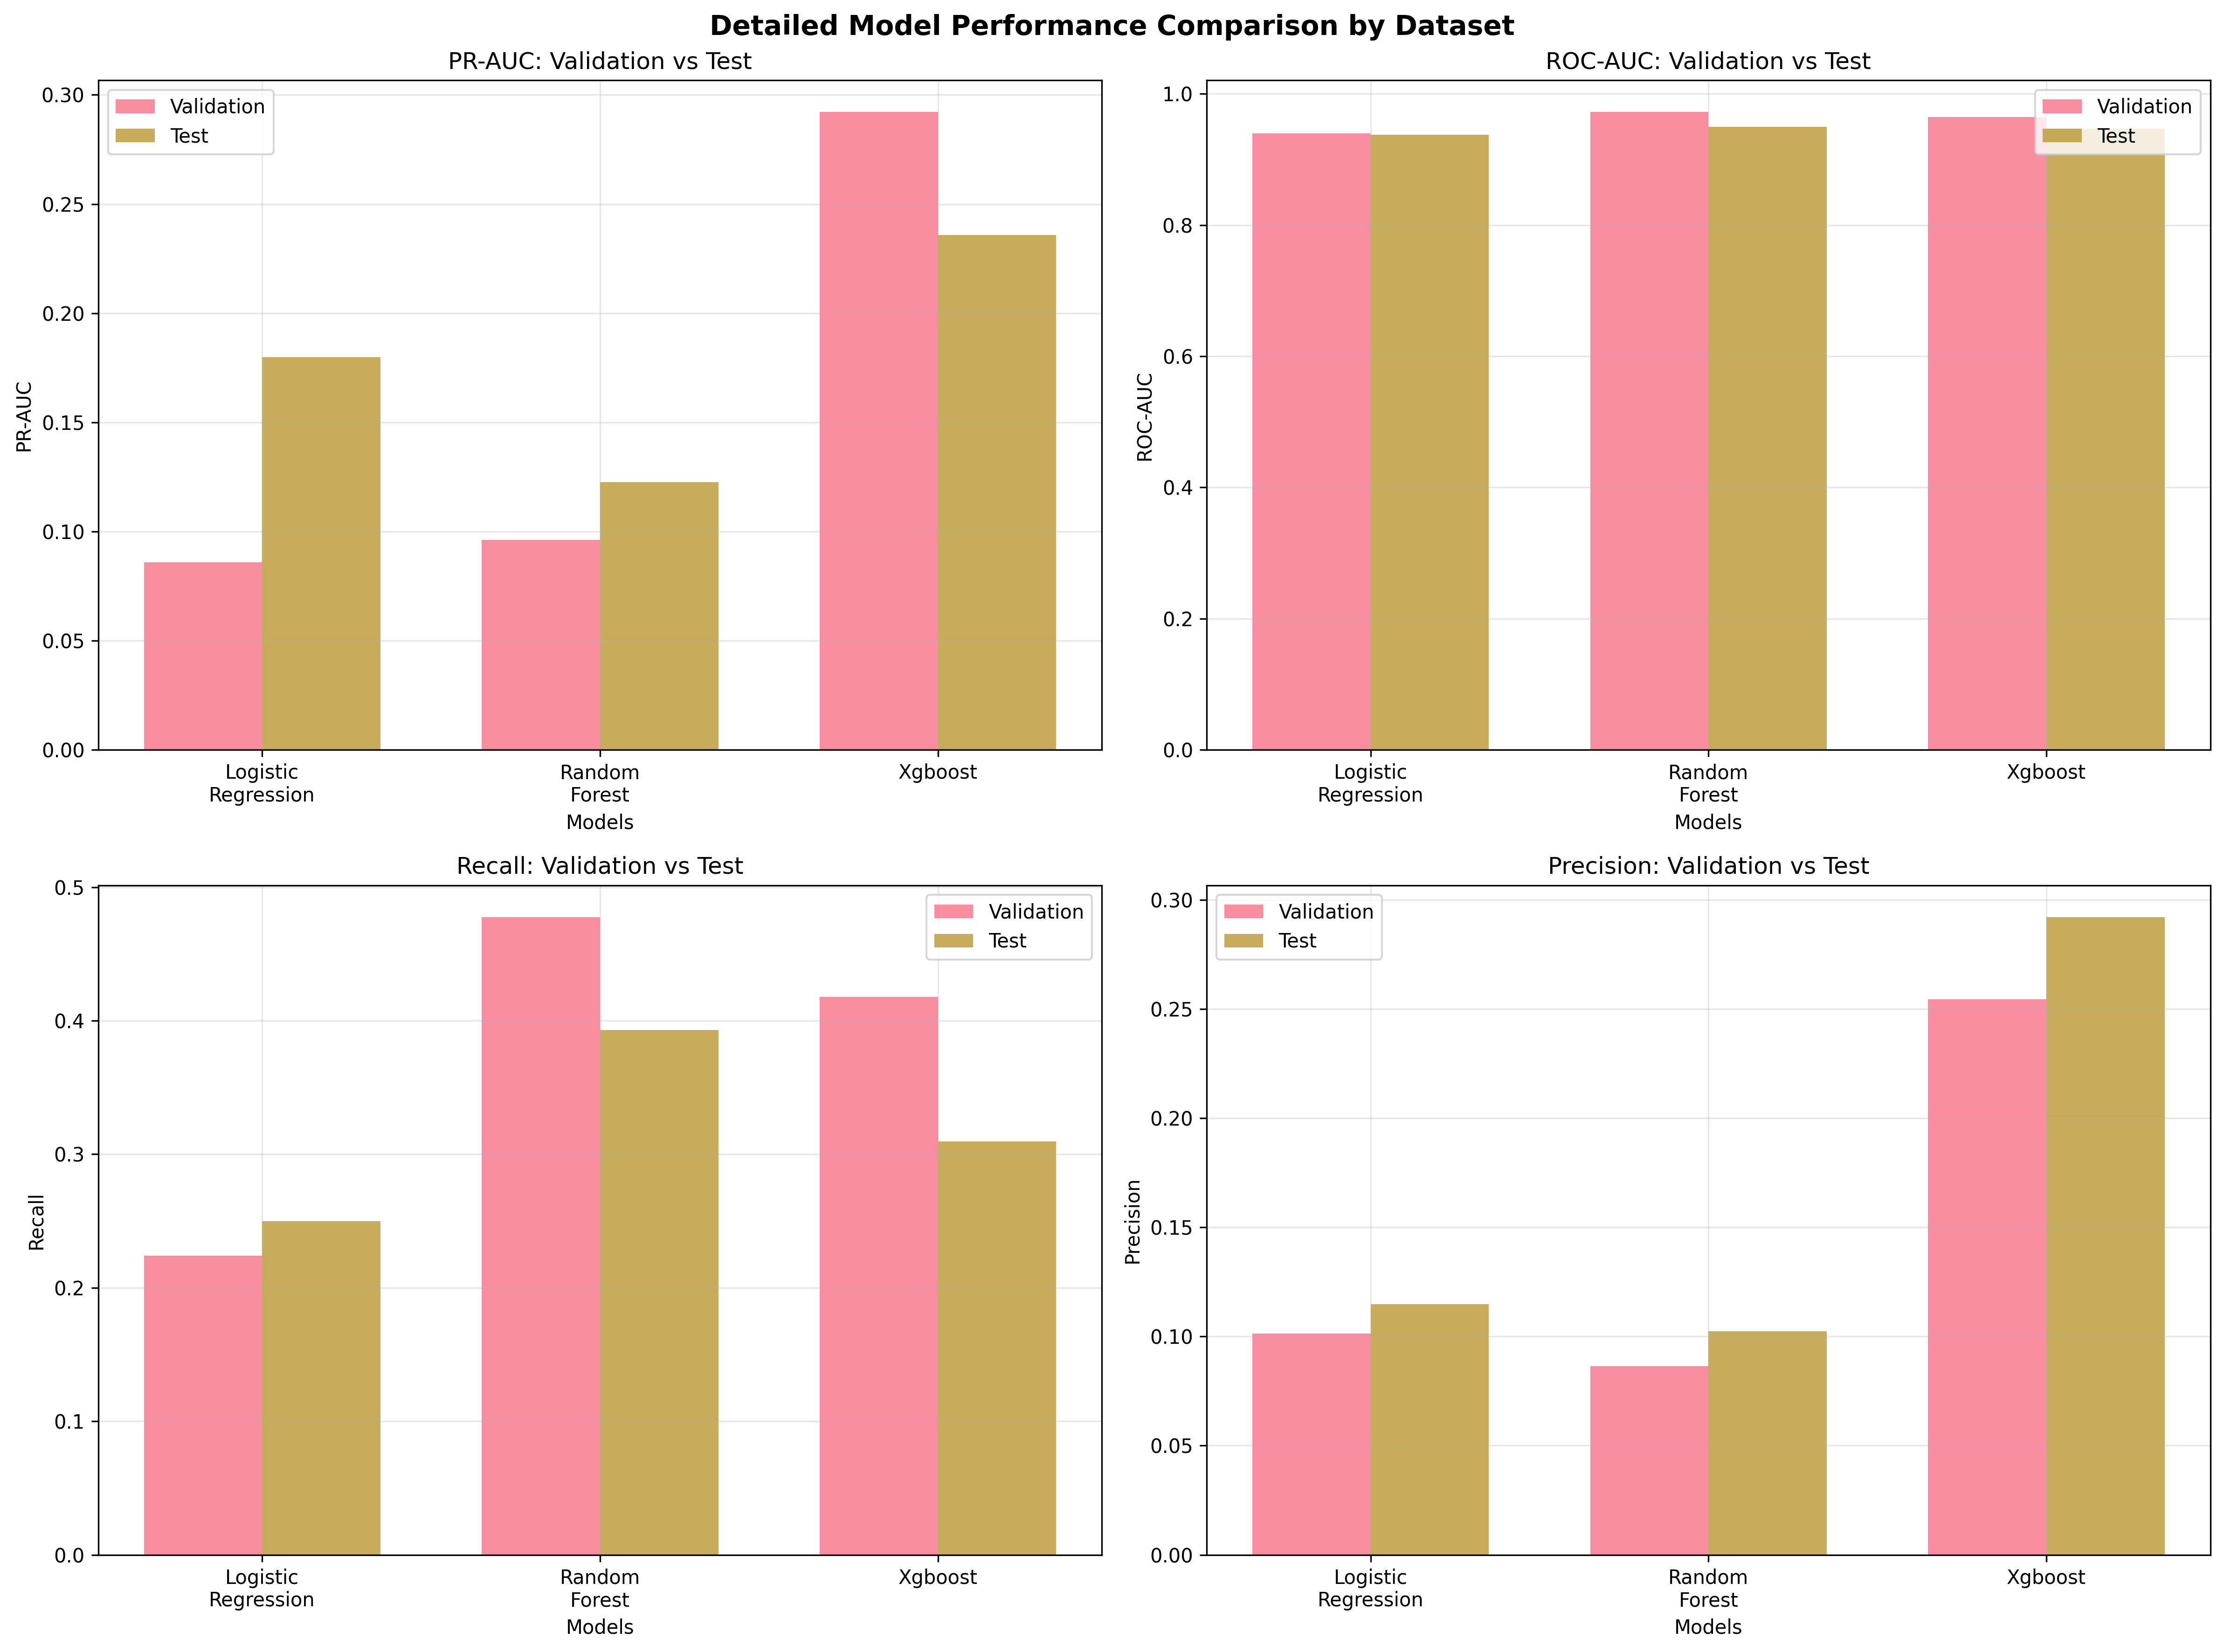


⚠️ Plot not found: score_drift_distribution.png


In [16]:
# Run plot generation script
!python ../create_results_plot.py

from IPython.display import Image, display

# List of important plots to show
plots_to_show = [
    'comprehensive_model_analysis.png',
    'detailed_dataset_comparison.png',
    'score_drift_distribution.png'
]

for plot_name in plots_to_show:
    plot_path = PLOTS_DIR / plot_name
    if plot_path.exists():
        print(f'\n🖼️ {plot_name}:')
        display(Image(filename=plot_path))
    else:
        print(f'\n⚠️ Plot not found: {plot_name}')


## 9. Next Steps

After validation is complete, you can proceed with:

1. **View MLflow experiments**: `mlflow ui --backend-store-uri mlruns`
2. **Run tests**: `python -m pytest tests/ -v`
3. **Deploy models**: Use the trained models for inference

### 📊 Expected Outputs

- **29 plot files** (3 models × 3 datasets × 3 plot types)
- **Comprehensive analysis plots** with ROC curves
- **Separate training/validation/test analysis**
- **Performance comparison tables** with best values highlighted